In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw.csv')

df.shape
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   str    
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   str    
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), str(2)
memory usage: 146.2 KB


Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [191]:
# Kiểm tra kiểu dữ liệu thực tế
print(df['Area'].apply(type).value_counts())

# Làm sạch chuỗi (nếu có dấu phẩy) và convert về số
df['Area'] = df['Area'].astype(str).str.replace(',', '').str.strip()
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

print("Số dòng lỗi convert (NaN):", df['Area'].isnull().sum())
df = df.dropna(subset=['Area'])

# Loại các dòng Area lỗi rõ ràng (giá trị hàng tỷ, không hợp lý cho diện tích nhà)
print("Số dòng Area > 10,000:", (df['Area'] > 10000).sum())
df = df[df['Area'] <= 10000]

Area
<class 'str'>    3479
Name: count, dtype: int64
Số dòng lỗi convert (NaN): 0
Số dòng Area > 10,000: 4


In [192]:
print("Số dòng Area > 2000:", (df['Area'] > 2000).sum())
df = df[df['Area'] <= 2000]

df['Area'].describe()

Số dòng Area > 2000: 1


count    3474.000000
mean      107.031664
std        70.991973
min        30.000000
25%        69.000000
50%        90.000000
75%       120.000000
max      1000.000000
Name: Area, dtype: float64

In [193]:
print(df[['Price', 'Price(USD)']].corr())
df = df.drop(columns=['Price'])

# Đổi tên cho gọn, tránh lỗi cú pháp với dấu ngoặc
df = df.rename(columns={'Price(USD)': 'Price_USD'})
target = 'Price_USD'

            Price  Price(USD)
Price         1.0         1.0
Price(USD)    1.0         1.0


In [194]:
numeric_cols = ['Area', 'Room']
boolean_cols = ['Parking', 'Warehouse', 'Elevator']
categorical_cols = ['Address']

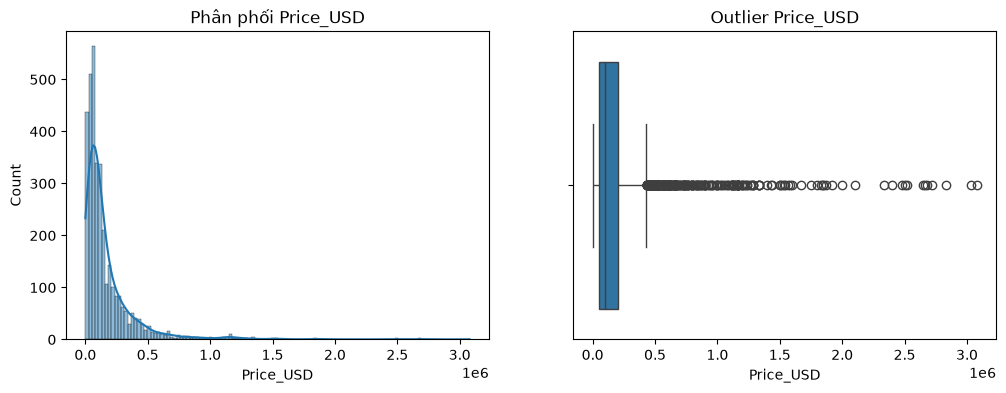

Skewness: 4.78136064205584


In [195]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title('Phân phối Price_USD')
sns.boxplot(x=df[target], ax=axes[1])
axes[1].set_title('Outlier Price_USD')
plt.show()

print("Skewness:", df[target].skew())

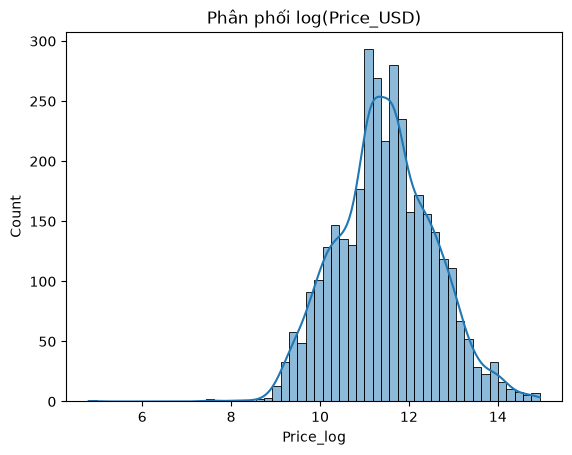

In [196]:
df['Price_log'] = np.log1p(df[target])
sns.histplot(df['Price_log'], kde=True)
plt.title('Phân phối log(Price_USD)')
plt.show()

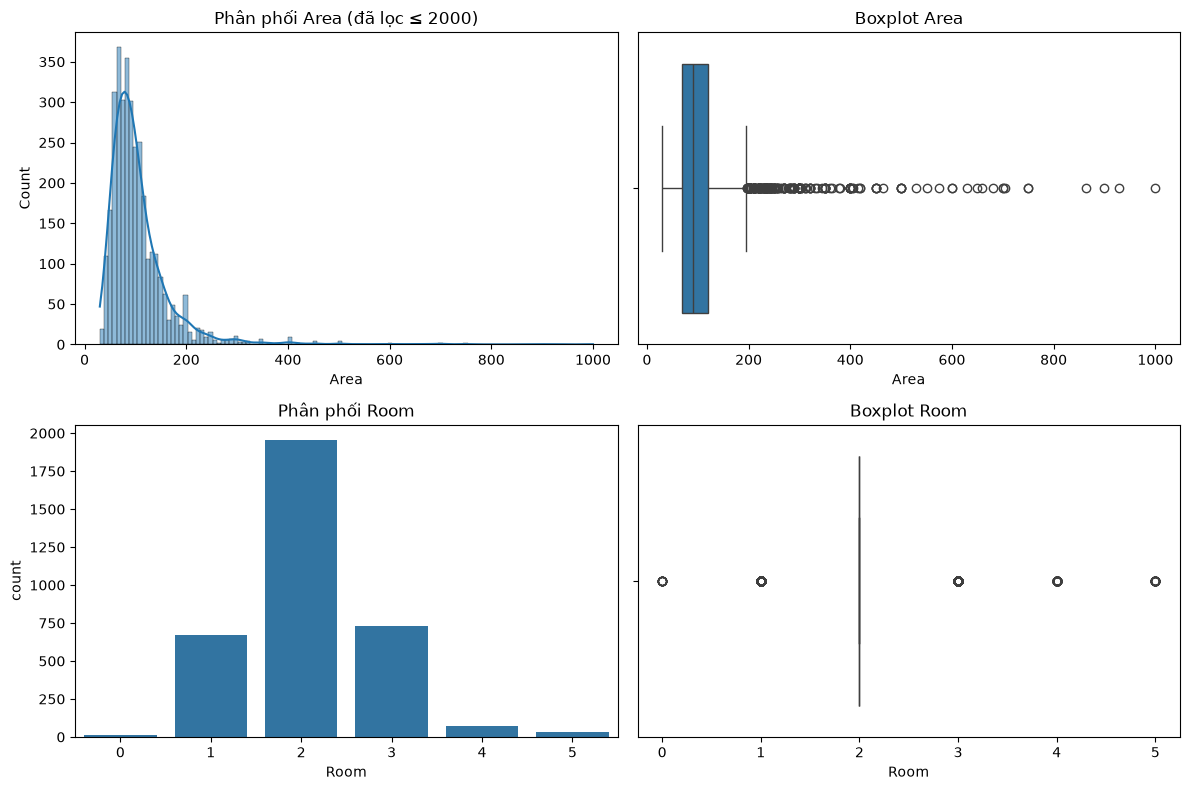

In [197]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['Area'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Phân phối Area (đã lọc ≤ 2000)')
sns.boxplot(x=df['Area'], ax=axes[0,1])
axes[0,1].set_title('Boxplot Area')

sns.countplot(x='Room', data=df, ax=axes[1,0])
axes[1,0].set_title('Phân phối Room')
sns.boxplot(x=df['Room'], ax=axes[1,1])
axes[1,1].set_title('Boxplot Room')
plt.tight_layout()
plt.show()

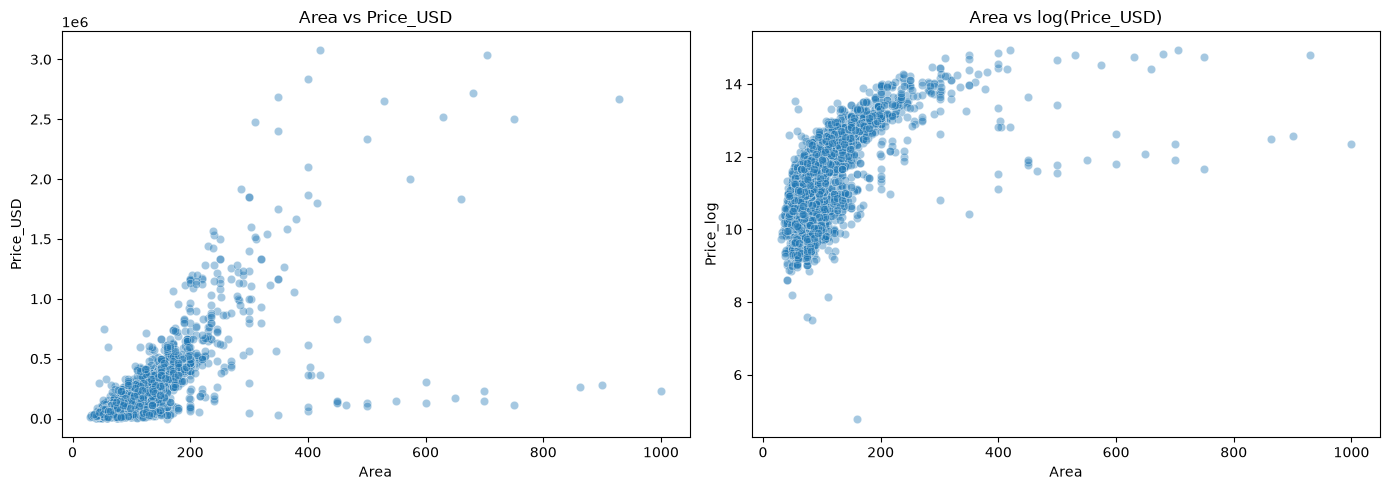

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='Area', y=target, data=df, alpha=0.4, ax=axes[0])
axes[0].set_title('Area vs Price_USD')

sns.scatterplot(x='Area', y='Price_log', data=df, alpha=0.4, ax=axes[1])
axes[1].set_title('Area vs log(Price_USD)')
plt.tight_layout()
plt.show()

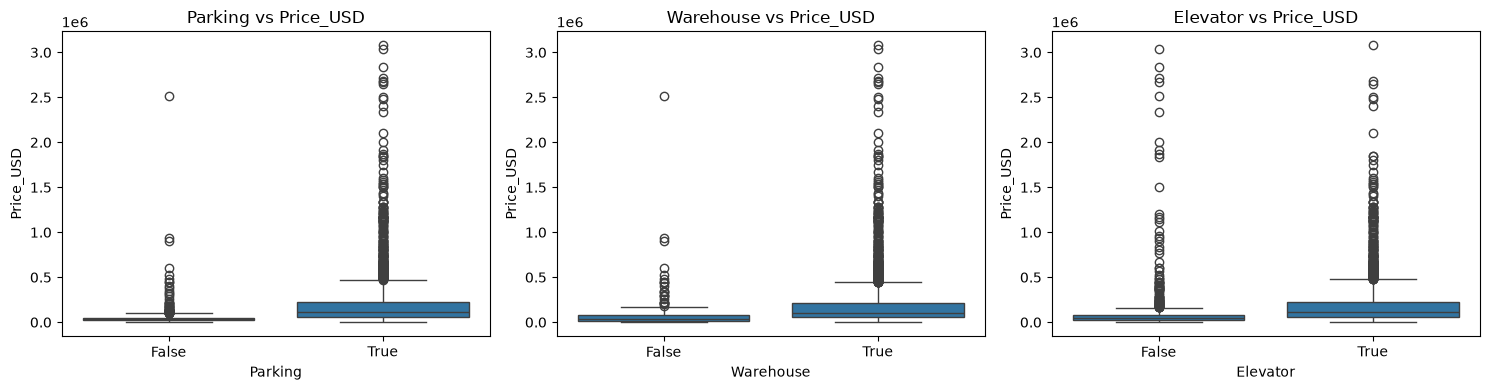

Parking
False     56949.350038
True     200288.779260
Name: Price_USD, dtype: float64

Warehouse
False     81176.700845
True     187568.186617
Name: Price_USD, dtype: float64

Elevator
False    120477.059161
True     194181.884388
Name: Price_USD, dtype: float64



In [199]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, boolean_cols):
    sns.boxplot(x=col, y=target, data=df, ax=ax)
    ax.set_title(f'{col} vs Price_USD')
plt.tight_layout()
plt.show()

for col in boolean_cols:
    print(df.groupby(col)[target].mean())
    print()

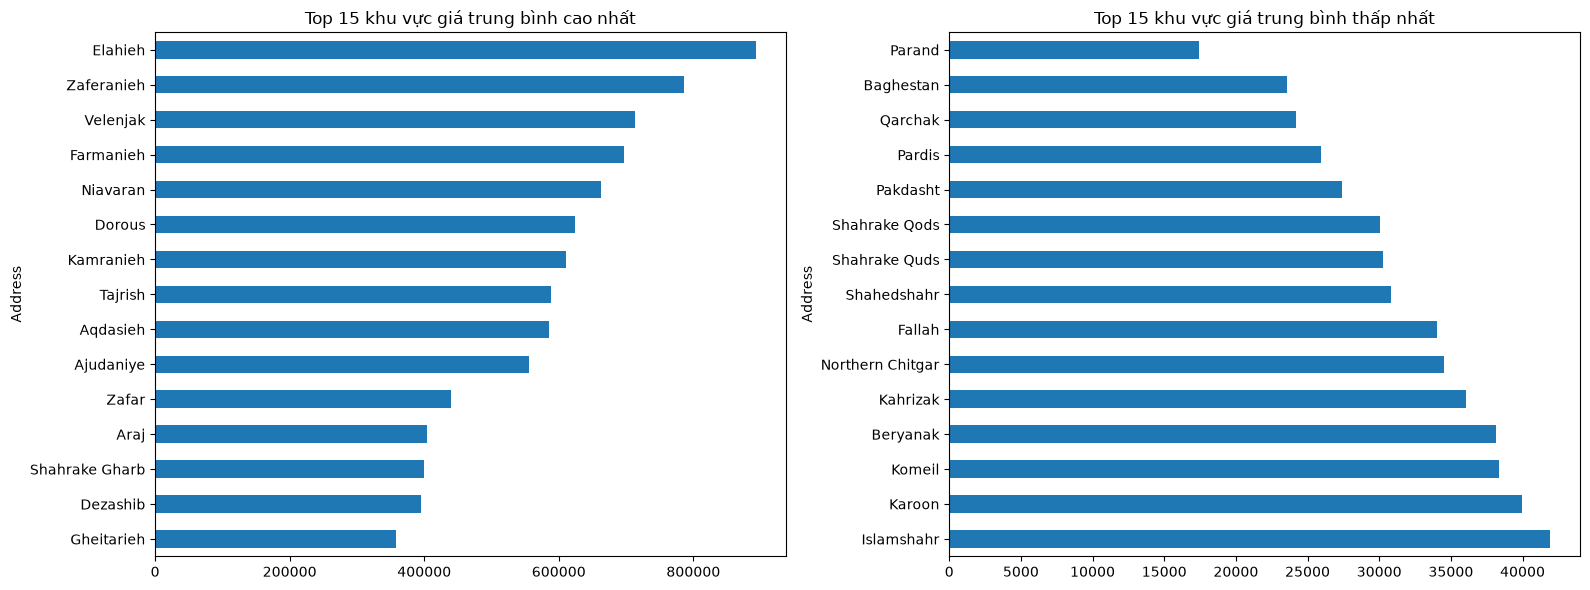

Tổng số khu vực (Address) khác nhau: 192


In [200]:
top_addr = df.groupby('Address')[target].agg(['mean','count']).sort_values('mean', ascending=False)
top_addr = top_addr[top_addr['count'] >= 5]   # lọc khu vực đủ số mẫu

fig, axes = plt.subplots(1, 2, figsize=(16,6))
top_addr.head(15)['mean'].plot(kind='barh', ax=axes[0])
axes[0].set_title('Top 15 khu vực giá trung bình cao nhất')
axes[0].invert_yaxis()

top_addr.tail(15)['mean'].plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 15 khu vực giá trung bình thấp nhất')
plt.tight_layout()
plt.show()

print("Tổng số khu vực (Address) khác nhau:", df['Address'].nunique())

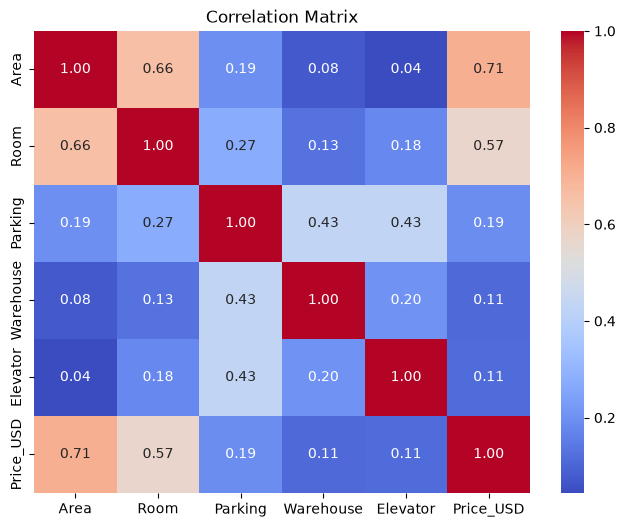

Price_USD    1.000000
Area         0.706721
Room         0.567599
Parking      0.190551
Elevator     0.111688
Warehouse    0.109987
Name: Price_USD, dtype: float64


In [201]:
corr_cols = ['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', target]
df_corr = df[corr_cols].copy()

for col in boolean_cols:
    df_corr[col] = df_corr[col].astype(int)

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

print(df_corr.corr()[target].sort_values(ascending=False))